In [2]:
from asyncio.windows_events import NULL

import numpy as np
import json
import pandas as pd
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt

import torchvision
from torchvision import transforms


In [10]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


train_val_dataset = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.EMNIST(
    root='./data', split='balanced' , train=False, download=True, transform=transform
)
val_ratio = 0.1
val_size = int(val_ratio * len(train_val_dataset))
train_size = len(train_val_dataset) - val_size
train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size])

In [5]:
BATCH_SIZE = 256 if device.type == "cuda" else 64

NUM_WORKERS = 0 if os.name == "nt" else 2


train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
   val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print(f"x min: {x_batch.min()}")
print(f"x max: {x_batch.max()}")
print("y_batch:", y_batch.shape, y_batch.dtype)


x_batch: torch.Size([64, 1, 28, 28]) torch.float32
x min: -1.0
x max: 1.0
y_batch: torch.Size([64]) torch.int64


In [6]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [7]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [8]:
def plot_history(history: dict, title: str = "") -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [9]:
def create_model(config):
    return MLP(
        input_dim=28*28,
        hidden_dims=config['hidden_dims'],
        num_classes=47,  # для EMNIST balanced
        activation=config.get('activation', 'relu'),
        dropout_p=config.get('dropout_p', 0.0),
        use_batchnorm=config.get('use_batchnorm', False)
    )

def create_optimizer(model, config):
    if config['optimizer'] == 'adam':
        return optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config.get('weight_decay', 0))
    elif config['optimizer'] == 'sgd':
        return optim.SGD(
            model.parameters(),
            lr=config['lr'],
            momentum=config.get('momentum', 0),
            weight_decay=config.get('weight_decay', 0)
        )
    else:
        raise ValueError(f"Unknown optimizer: {config['optimizer']}")

def train_experiment(config, train_loader, val_loader, test_loader=None, device='cpu'):
    model = create_model(config).to(device)
    optimizer = create_optimizer(model, config)
    criterion = nn.CrossEntropyLoss()
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    best_val_acc = 0.0
    best_model_state = None
    patience_counter = 0

    print(f"\nЭксперимент: {config['name']}")
    print(f"Конфиг: {config}")
    print("-" * 60)

    for epoch in range(1, config['epochs'] + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)

        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Эпоха {epoch}: train_loss={train_loss}, train_acc={train_acc:} | "
              f"val_loss={val_loss}, val_acc={val_acc}")

        if config.get('use_early_stopping', False):
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = model.state_dict().copy()
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= config.get('patience', 3):
                print(f"Early stopping на эпохе {epoch}")
                break

    if config.get('use_early_stopping', False) and best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Загружена лучшая модель с val_acc={best_val_acc}")

    if test_loader is not None:
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        print(f"Test accuracy: {test_acc}")
        history['test_acc'] = test_acc

    return model, history

def log_experiment_to_csv(config, history, filename='artifacts/runs.csv'):

    os.makedirs(os.path.dirname(filename), exist_ok=True)

    # Формируем model_summary
    hidden_sizes = '/'.join(str(h) for h in config['hidden_dims'])
    activation = config.get('activation', 'relu')
    dropout = config.get('dropout_p', 0.0)
    batchnorm = config.get('use_batchnorm', False)

    model_summary = f"hidden=[{hidden_sizes}], activation={activation}, dropout={dropout}, batchnorm={batchnorm}"

    # Добавляем информацию о early stopping если есть
    if config.get('use_early_stopping', False):
        model_summary += f", early_stopping=True(patience={config.get('patience', 3)})"

    # Подготавливаем результат согласно требованиям
    result = {
        'experiment_id': config['name'],  # E1, E2, E3, E4, O1, O2, O3
        'dataset': config.get('dataset', 'EMNIST'),
        'seed': config.get('seed', 42),
        'model_summary': model_summary,
        'optimizer': config['optimizer'],
        'lr': config['lr'],
        'momentum': config.get('momentum', 0.0),  # 0 для Adam
        'weight_decay': config.get('weight_decay', 0.0),
        'epochs_trained': len(history['train_loss']),
        'best_val_accuracy': max(history['val_acc']),
        'best_val_loss': min(history['val_loss'])
    }

    # Создаем DataFrame
    df = pd.DataFrame([result])

    # Проверяем порядок колонок как в задании
    column_order = [
        'experiment_id', 'dataset', 'seed', 'model_summary',
        'optimizer', 'lr', 'momentum', 'weight_decay',
        'epochs_trained', 'best_val_accuracy', 'best_val_loss'
    ]
    df = df[column_order]

    # Сохраняем (добавляем к существующему файлу)
    if os.path.exists(filename):
        existing = pd.read_csv(filename)
        df = pd.concat([existing, df], ignore_index=True)

    df.to_csv(filename, index=False)

In [10]:
config_e1 = {
    'name': 'E1',
    'hidden_dims': (256, 128),
    'dropout_p': 0.0,
    'use_batchnorm': False,
    'optimizer': 'adam',
    'lr': 0.001,
    'epochs': 15
}

config_e2 = {
    'name': 'E2',
    'hidden_dims': (256, 128),
    'dropout_p': 0.3,
    'use_batchnorm': False,
    'optimizer': 'adam',
    'lr': 0.001,
    'epochs': 15
}

config_e3 = {
    'name': 'E3',
    'hidden_dims': (256, 128),
    'dropout_p': 0.0,
    'use_batchnorm': True,
    'optimizer': 'adam',
    'lr': 0.001,
    'epochs': 15
}



In [11]:
model_e1, history_e1 = train_experiment(config_e1, train_loader, val_loader, device=device)
log_experiment_to_csv(config_e1, history_e1)


Эксперимент: E1
Конфиг: {'name': 'E1', 'hidden_dims': (256, 128), 'dropout_p': 0.0, 'use_batchnorm': False, 'optimizer': 'adam', 'lr': 0.001, 'epochs': 15}
------------------------------------------------------------
Эпоха 1: train_loss=1.171387741033067, train_acc=0.6556405141843972 | val_loss=0.7933957590259844, val_acc=0.7537623937677054
Эпоха 2: train_loss=0.6776904616372805, train_acc=0.7821808510638298 | val_loss=0.675074411181485, val_acc=0.7841713881019831
Эпоха 3: train_loss=0.5737977695697588, train_acc=0.8106937056737589 | val_loss=0.6116192275842931, val_acc=0.8020980878186968
Эпоха 4: train_loss=0.5162471458738578, train_acc=0.8244126773049646 | val_loss=0.5498525863328669, val_acc=0.8204674220963173
Эпоха 5: train_loss=0.4791495305215213, train_acc=0.8342087765957447 | val_loss=0.534563247990338, val_acc=0.8267970963172805
Эпоха 6: train_loss=0.45187559595978855, train_acc=0.8418882978723404 | val_loss=0.5265177799014127, val_acc=0.828257790368272
Эпоха 7: train_loss=0.4

In [12]:
model_e2, history_e2 = train_experiment(config_e2, train_loader, val_loader, device=device)
log_experiment_to_csv(config_e2, history_e2)


Эксперимент: E2
Конфиг: {'name': 'E2', 'hidden_dims': (256, 128), 'dropout_p': 0.3, 'use_batchnorm': False, 'optimizer': 'adam', 'lr': 0.001, 'epochs': 15}
------------------------------------------------------------
Эпоха 1: train_loss=1.5506158365425489, train_acc=0.548614804964539 | val_loss=0.8781261184060202, val_acc=0.7334012039660056
Эпоха 2: train_loss=1.046110453335106, train_acc=0.6766179078014184 | val_loss=0.7234019624443973, val_acc=0.7735481586402266
Эпоха 3: train_loss=0.9416848942109034, train_acc=0.7058399822695035 | val_loss=0.6736532092600976, val_acc=0.7841271246458924
Эпоха 4: train_loss=0.890871040723848, train_acc=0.7167442375886525 | val_loss=0.6346054907898727, val_acc=0.7974061614730878
Эпоха 5: train_loss=0.8560446791615046, train_acc=0.7275155141843972 | val_loss=0.6302482627606595, val_acc=0.7967864730878187
Эпоха 6: train_loss=0.8362834764287826, train_acc=0.7335882092198581 | val_loss=0.6020068833578072, val_acc=0.8014341359773371
Эпоха 7: train_loss=0.8

In [13]:
model_e3, history_e3 = train_experiment(config_e3, train_loader, val_loader, device=device)
log_experiment_to_csv(config_e3, history_e3)


Эксперимент: E3
Конфиг: {'name': 'E3', 'hidden_dims': (256, 128), 'dropout_p': 0.0, 'use_batchnorm': True, 'optimizer': 'adam', 'lr': 0.001, 'epochs': 15}
------------------------------------------------------------
Эпоха 1: train_loss=0.9161524668864325, train_acc=0.7367021276595744 | val_loss=0.5667549192736574, val_acc=0.8177673512747875
Эпоха 2: train_loss=0.5373859250587775, train_acc=0.8212101063829788 | val_loss=0.5007399584011045, val_acc=0.8329939801699717
Эпоха 3: train_loss=0.46332290877475807, train_acc=0.8400820035460993 | val_loss=0.4842419988203994, val_acc=0.8351186260623229
Эпоха 4: train_loss=0.42074365595765145, train_acc=0.8507757092198581 | val_loss=0.4582516485587733, val_acc=0.8442811614730878
Эпоха 5: train_loss=0.3899624878421743, train_acc=0.8601507092198581 | val_loss=0.4523495830405535, val_acc=0.8487075070821529
Эпоха 6: train_loss=0.3633708103117368, train_acc=0.867542109929078 | val_loss=0.4516317349655432, val_acc=0.8474238668555241
Эпоха 7: train_loss=

In [14]:
print("\nСравнение результатов")
print(f"E1 (base) - best val_acc: {max(history_e1['val_acc'])}")
print(f"E2 (dropout) - best val_acc: {max(history_e2['val_acc'])}")
print(f"E3 (batchnorm) - best val_acc: {max(history_e3['val_acc'])}")


best_val_accs = {
    'E2': max(history_e2['val_acc']),
    'E3': max(history_e3['val_acc'])
}
best_config_name = max(best_val_accs, key=best_val_accs.get)


Сравнение результатов
E1 (base) - best val_acc: 0.8340563031161473
E2 (dropout) - best val_acc: 0.8214854815864022
E3 (batchnorm) - best val_acc: 0.8529567988668555


In [15]:
config_e4 = {
    'name': 'E4',
    'hidden_dims': (256, 128),
    'dropout_p': 0.3 if best_config_name == 'E2' else 0.0,
    'use_batchnorm': True if best_config_name == 'E3' else False,
    'optimizer': 'adam',
    'lr': 0.001,
    'epochs': 30,
    'use_early_stopping': True,
    'patience': 4
}


Лучший конфиг для early stopping: E3

Эксперимент: E4
Конфиг: {'name': 'E4', 'hidden_dims': (256, 128), 'dropout_p': 0.0, 'use_batchnorm': True, 'optimizer': 'adam', 'lr': 0.001, 'epochs': 30, 'use_early_stopping': True, 'patience': 4}
------------------------------------------------------------
Эпоха 1: train_loss=0.9204705047691968, train_acc=0.7344968971631206 | val_loss=0.5862210229165831, val_acc=0.8059490084985835
Эпоха 2: train_loss=0.5366616276984519, train_acc=0.8204122340425531 | val_loss=0.5005226844430983, val_acc=0.8347202549575071
Эпоха 3: train_loss=0.4648902413481516, train_acc=0.8398160460992907 | val_loss=0.4752500200322262, val_acc=0.8391908640226629
Эпоха 4: train_loss=0.42366228309717585, train_acc=0.8499224290780142 | val_loss=0.47273277514548206, val_acc=0.8383498583569405
Эпоха 5: train_loss=0.3903109719461583, train_acc=0.8600288120567375 | val_loss=0.45216768937813323, val_acc=0.8464058073654391
Эпоха 6: train_loss=0.36560831161889623, train_acc=0.86613475177

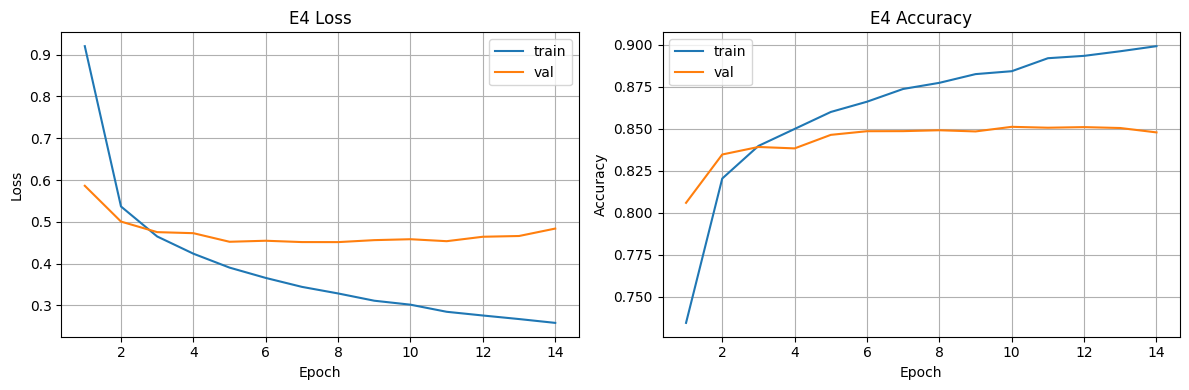

In [16]:


print(f"\nЛучший конфиг для early stopping: {best_config_name}")
model_e4, history_e4 = train_experiment(config_e4, train_loader, val_loader, test_loader, device=device)
log_experiment_to_csv(config_e4, history_e4)
torch.save(model_e4.state_dict(), 'artifacts/best_model.pt')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history_e4['train_loss']) + 1)

ax1.plot(epochs, history_e4['train_loss'], label='train')
ax1.plot(epochs, history_e4['val_loss'], label='val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('E4 Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, history_e4['train_acc'], label='train')
ax2.plot(epochs, history_e4['val_acc'], label='val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('E4 Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_best.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
base_architecture = (256, 128)
use_bn = config_e4['use_batchnorm']
dropout_p = config_e4['dropout_p']

In [18]:
# 3.2 Часть B: эксперименты с LR и оптимизаторами

# Используем архитектуру из E4


# O1: Слишком большой LR
config_o1 = {
    'name': 'O1_lr_too_high',
    'hidden_dims': base_architecture,
    'dropout_p': dropout_p,
    'use_batchnorm': use_bn,
    'optimizer': 'adam',
    'lr': 0.1,  # слишком большой
    'epochs': 8
}

# O2: Слишком маленький LR


# O3: SGD + momentum + weight decay


# Проводим эксперименты
print("\nЧасть B: Эксперименты с LR и оптимизаторами")

model_o1, history_o1 = train_experiment(config_o1, train_loader, val_loader, device=device)
log_experiment_to_csv(config_o1, history_o1)



Часть B: Эксперименты с LR и оптимизаторами

Эксперимент: O1_lr_too_high
Конфиг: {'name': 'O1_lr_too_high', 'hidden_dims': (256, 128), 'dropout_p': 0.0, 'use_batchnorm': True, 'optimizer': 'adam', 'lr': 0.1, 'epochs': 8}
------------------------------------------------------------
Эпоха 1: train_loss=1.229369168247737, train_acc=0.6334773936170213 | val_loss=0.9389035926324449, val_acc=0.7124645892351275
Эпоха 2: train_loss=0.8938957892411145, train_acc=0.7208998226950355 | val_loss=0.7490118747898945, val_acc=0.7620396600566572
Эпоха 3: train_loss=0.824900105024906, train_acc=0.7391843971631206 | val_loss=0.7910708902408989, val_acc=0.7565509915014165
Эпоха 4: train_loss=0.7760714747804276, train_acc=0.7525487588652482 | val_loss=0.6812869276608692, val_acc=0.7826221671388102
Эпоха 5: train_loss=0.7372275322887069, train_acc=0.7626218971631206 | val_loss=0.6982722783054913, val_acc=0.7794351983002833
Эпоха 6: train_loss=0.7129341039674502, train_acc=0.7694259751773049 | val_loss=0.65

In [19]:
config_o2 = {
    'name': 'O2_lr_too_low',
    'hidden_dims': base_architecture,
    'dropout_p': dropout_p,
    'use_batchnorm': use_bn,
    'optimizer': 'adam',
    'lr': 1e-5,  # слишком маленький
    'epochs': 8
}

model_o2, history_o2 = train_experiment(config_o2, train_loader, val_loader, device=device)
log_experiment_to_csv(config_o2, history_o2)





Эксперимент: O2_lr_too_low
Конфиг: {'name': 'O2_lr_too_low', 'hidden_dims': (256, 128), 'dropout_p': 0.0, 'use_batchnorm': True, 'optimizer': 'adam', 'lr': 1e-05, 'epochs': 8}
------------------------------------------------------------
Эпоха 1: train_loss=3.310009645908437, train_acc=0.24844858156028368 | val_loss=2.8885045774259916, val_acc=0.42767351274787535
Эпоха 2: train_loss=2.663412016165172, train_acc=0.49361702127659574 | val_loss=2.424037921867695, val_acc=0.5478045325779037
Эпоха 3: train_loss=2.2916590397239576, train_acc=0.5732823581560283 | val_loss=2.1141236081677186, val_acc=0.60530276203966
Эпоха 4: train_loss=2.009373034145815, train_acc=0.6163231382978723 | val_loss=1.8612864314665538, val_acc=0.6400053116147308
Эпоха 5: train_loss=1.784503394914857, train_acc=0.6456227836879432 | val_loss=1.6521607113965173, val_acc=0.6625354107648725
Эпоха 6: train_loss=1.6011028151985602, train_acc=0.6688940602836879 | val_loss=1.5027677952061294, val_acc=0.6830736543909348
Эпох

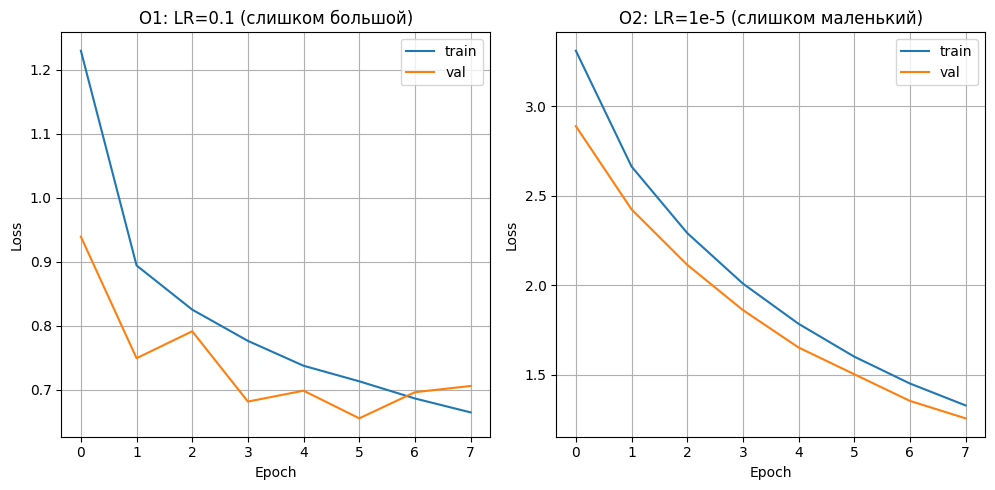

In [20]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history_o1['train_loss'], label='train')
plt.plot(history_o1['val_loss'], label='val')
plt.title('O1: LR=0.1 (слишком большой)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.subplot(1, 3, 2)
plt.plot(history_o2['train_loss'], label='train')
plt.plot(history_o2['val_loss'], label='val')
plt.title('O2: LR=1e-5 (слишком маленький)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=150, bbox_inches='tight')
plt.show()


Эксперимент: O3_sgd_momentum_wd
Конфиг: {'name': 'O3_sgd_momentum_wd', 'hidden_dims': (256, 128), 'dropout_p': 0.0, 'use_batchnorm': True, 'optimizer': 'sgd', 'lr': 0.01, 'momentum': 0.9, 'weight_decay': 0.0001, 'epochs': 12}
------------------------------------------------------------
Эпоха 1: train_loss=0.961594890977474, train_acc=0.722229609929078 | val_loss=0.6191039276190587, val_acc=0.8026292492917847
Эпоха 2: train_loss=0.5654426755634605, train_acc=0.8122118794326241 | val_loss=0.5322021433381792, val_acc=0.8268413597733711
Эпоха 3: train_loss=0.4864052617275123, train_acc=0.8349623226950355 | val_loss=0.4934990745850393, val_acc=0.8362694759206799
Эпоха 4: train_loss=0.4425395960609118, train_acc=0.8466644503546099 | val_loss=0.4805470460619535, val_acc=0.8382170679886686
Эпоха 5: train_loss=0.4108445720152652, train_acc=0.8550531914893617 | val_loss=0.4592397044552622, val_acc=0.8456090651558074
Эпоха 6: train_loss=0.3865883807024212, train_acc=0.8627105496453901 | val_loss

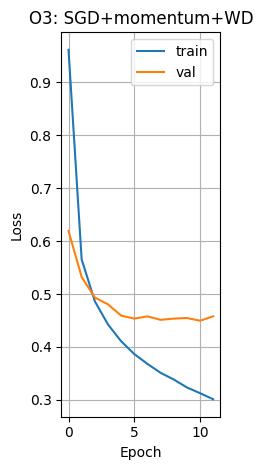

In [21]:
config_o3 = {
    'name': 'O3_sgd_momentum_wd',
    'hidden_dims': base_architecture,
    'dropout_p': dropout_p,
    'use_batchnorm': use_bn,
    'optimizer': 'sgd',
    'lr': 0.01,  # разумный LR для SGD
    'momentum': 0.9,
    'weight_decay': 1e-4,
    'epochs': 12
}

model_o3, history_o3 = train_experiment(config_o3, train_loader, val_loader, device=device)
log_experiment_to_csv(config_o3, history_o3)

plt.subplot(1, 3, 3)
plt.plot(history_o3['train_loss'], label='train')
plt.plot(history_o3['val_loss'], label='val')
plt.title('O3: SGD+momentum+WD')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
best_config = {
  "hidden_sizes": [
    256,
    128
  ],
  "dropout_p": 0.0,
  "use_batchnorm": True,
  "optimizer": "Adam",
  "lr": 0.001,
  "momentum": 0.0,
  "weight_decay": 0.0,
  "dataset": "EMNIST",
  "seed": 42,
  "fast_mode": True,
  "epochs_trained": 14,
  "best_val_accuracy": 0.8511862606232294,
  "best_val_loss": 0.451357261232884,
}

# Сохраняем в JSON
with open('artifacts/best_config.json', 'w', encoding='utf-8') as f:
    json.dump(best_config, f, indent=4, ensure_ascii=False)